# Analyses

Isaac T. Petersen, Zachary Demko, and Megan Schumer  
June 10, 2026

# Intro

# Preamble

## Install Libraries

In [ ]:
#install.packages("remotes")
#remotes::install_github("DevPsyLab/petersenlab")

## Load Libraries

In [ ]:
#| message: false
#| warning: false

library("petersenlab") #located here: https://github.com/DevPsyLab/petersenlab
library("tidyverse")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

## Load Data

In [ ]:
getwd()

[1] "/home/runner/work/studying-psychopathology-development-lifespan/studying-psychopathology-development-lifespan/notebooks"

Rows: 10 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): study, studyLabel, country, continent
dbl (7): yearStart, yearMostRecentAssessment, yearEnd, ageStartMin, ageStart...
num (1): sampleSize
lgl (1): prenatal

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.

# Plots

## Longitudinal Studies

In [ ]:
longitudinalStudies_plotData <- bind_rows(
  longitudinalStudies %>%
    mutate(
      segment_group = "cross-section",
      segment_type = "start_crossSection",
      ageStart = ageStartMin,
      ageEnd = ageStartMax
    ) %>%
    select(study, studyLabel, ageStart, ageEnd, segment_group, segment_type),

  longitudinalStudies %>%
    mutate(
      segment_group = "core",
      segment_type = "core",
      ageStart = ageStartMax,
      ageEnd = ageEndMin
    ) %>%
    select(study, studyLabel, ageStart, ageEnd, segment_group, segment_type),

  longitudinalStudies %>%
    mutate(
      segment_group = "cross-section",
      segment_type = "end_crossSection",
      ageStart = ageEndMin,
      ageEnd = ageEndMax
    ) %>%
    select(study, studyLabel, ageStart, ageEnd, segment_group, segment_type),
)

study_order <- longitudinalStudies %>%
  arrange(ageEndMax) %>%
  pull(studyLabel)

longitudinalStudies_plotData <- longitudinalStudies_plotData %>%
  mutate(studyLabelFactor = factor(studyLabel, levels = study_order))

prenatal_df <- longitudinalStudies %>%
  filter(prenatal == TRUE) %>%
  mutate(age = 0)

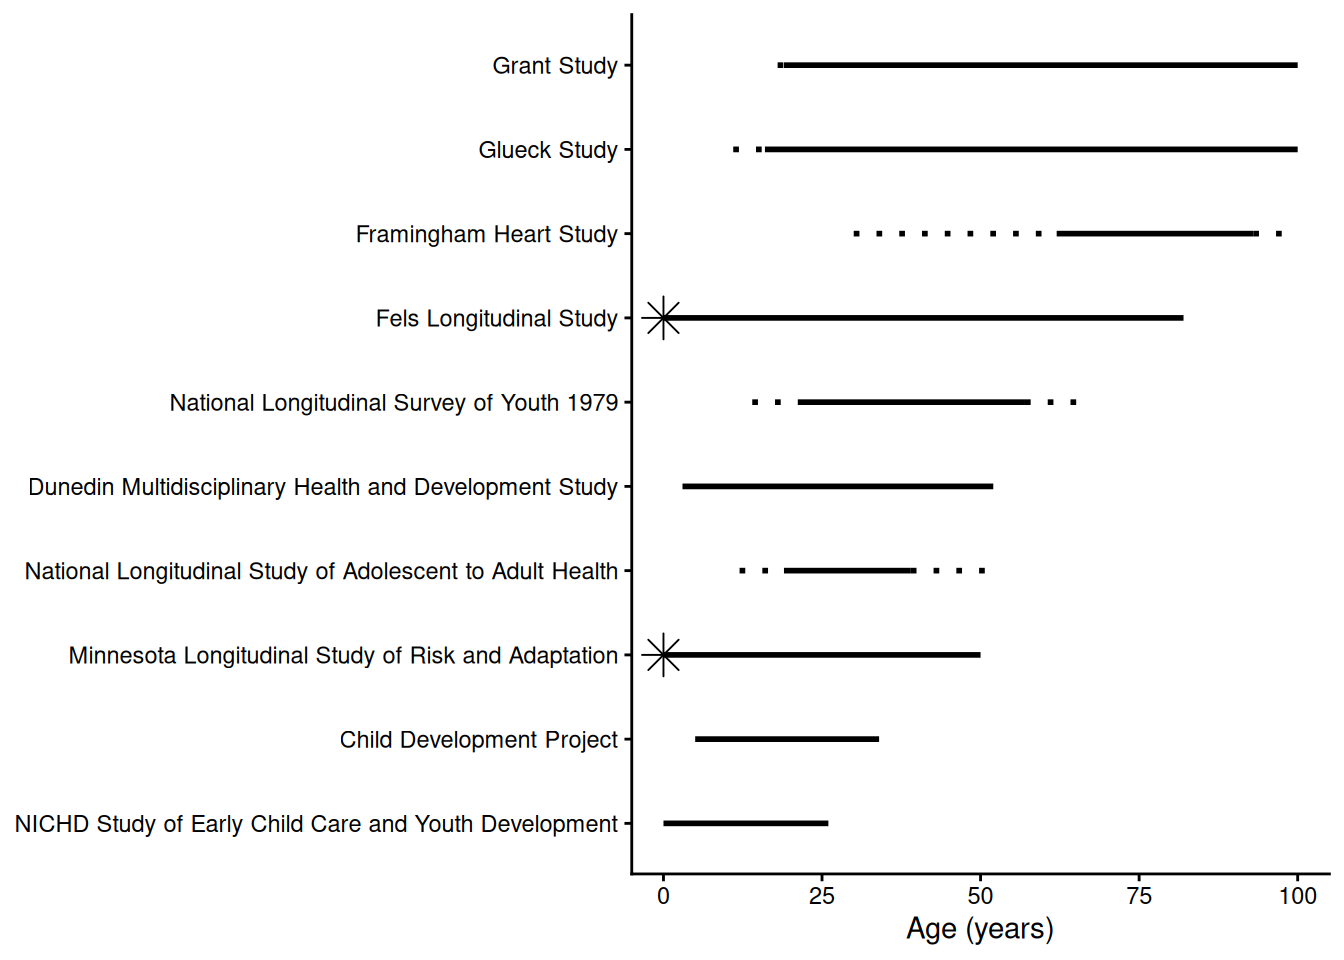

In [ ]:
#| label: fig-longitudinalstudies
#| fig-cap: "Ages spanned by various longitudinal studies. Dotted lines reflect cross-sectional spans. For instance, if a study recruited 5–10-year-old children and followed each child for 20 years, the study would have dotted lines from ages 5–10 and from ages 20–25. A star at age 0 represents that participants were enrolled before birth and the study included prenatal assessments. We truncated age at 100. Age 100 represents that the study has followed individuals into their 90s (or until they decease)."
#| fig-alt: "Ages spanned by various longitudinal studies. Dotted lines reflect cross-sectional spans. For instance, if a study recruited 5–10-year-old children and followed each child for 20 years, the study would have dotted lines from ages 5–10 and from ages 20–25. A star at age 0 represents that participants were enrolled before birth and the study included prenatal assessments. We truncated age at 100. Age 100 represents that the study has followed individuals into their 90s (or until they decease)."

plot_longitudinalStudies <- ggplot2::ggplot(
  data = longitudinalStudies_plotData,
  mapping = aes(
    y = studyLabelFactor
  )
) +
  geom_segment(
    aes(
      x = ageStart,
      xend = ageEnd,
      yend = studyLabel,
      linetype = segment_group),
    linewidth = 1
  ) +
  scale_linetype_manual(
    values = c(
      "cross-section" = "dotted",
      "core" = "solid"
    ),
    guide = "none"
  ) +
  geom_point(
    data = prenatal_df,
    aes(
      x = age,
      y = studyLabel),
    shape = 8, # star
    size = 5
  ) +
  labs(
    x = "Age (years)",
    y = NULL) +
  theme_classic()

plot_longitudinalStudies

# Session Info

In [ ]:
sessionInfo()

R version 4.6.0 (2026-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] lubridate_1.9.5   forcats_1.0.1     stringr_1.6.0     dplyr_1.2.1      
 [5] purrr_1.2.2       readr_2.2.0       tidyr_1.3.2       tibble_3.3.1     
 [9] ggplot2_4.0.3     tidyverse_2.0.0   petersenlab_1.2.3

loaded via a namespace (and

## Rstudio Version

In [ ]:
#rstudioapi::versionInfo()